In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('goodstack.csv')
df = df[df['CREATED_AT'] >= '2022-01-01']
df["FOUNDATION_NAME"] = df["FOUNDATION_NAME"].fillna("no_foundation")

# Convert CREATED_AT to datetime early (used everywhere)
df["CREATED_AT"] = pd.to_datetime(df["CREATED_AT"], errors="coerce")


In [5]:
df_failed = df[df['DONATION_STATUS'] == 'unable_to_pay']
df_success = df[df['DONATION_STATUS'] != 'unable_to_pay']

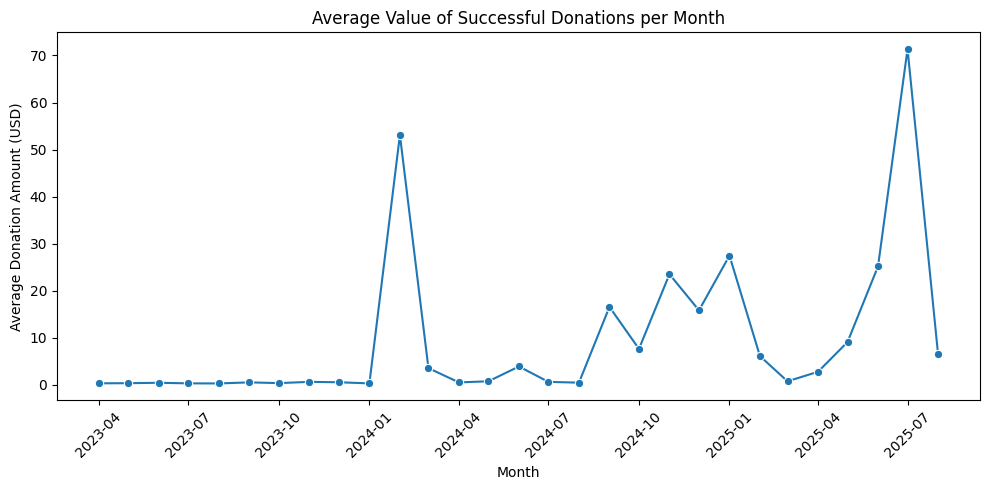

In [6]:
# Average successful donation value per month
monthly_avg = (
    df_success
    .dropna(subset=["CREATED_AT", "DONATION_AMOUNT_USD"])
    .set_index("CREATED_AT")
    .resample("MS")["DONATION_AMOUNT_USD"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_avg, x="CREATED_AT", y="DONATION_AMOUNT_USD", marker="o")
plt.title("Average Value of Successful Donations per Month")
plt.xlabel("Month")
plt.ylabel("Average Donation Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

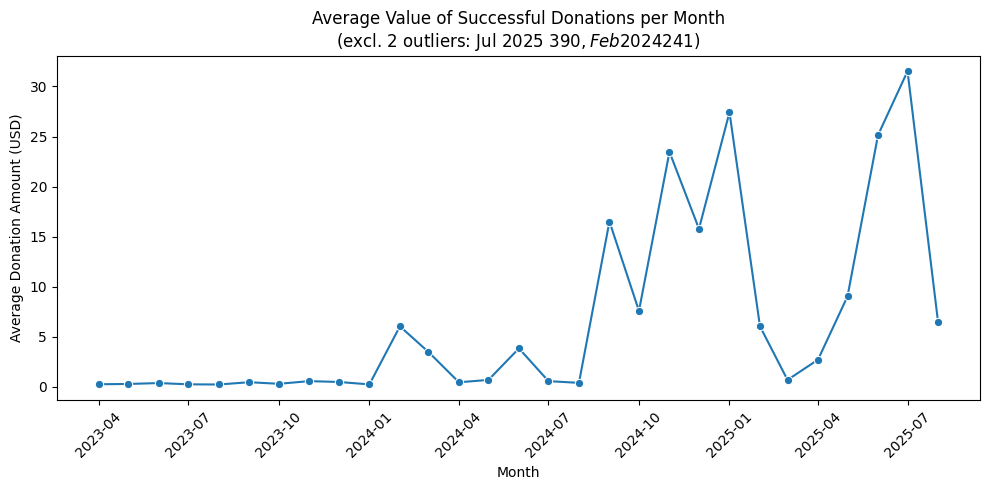

In [37]:
# Average successful donation value per month — outliers excluded
OUTLIER_IDS = {
    "donation_000000D88ROd0K6tOortLuPZjW4sm",  # $390, Jul 2025, Organisation_Name_48
    "donation_000000CnUa1RaaS6y5b8jD7Qc6Oh6",  # $241, Feb 2024, Organisation_Name_57
}

monthly_avg_excl = (
    df_success[~df_success["DONATION_ID"].isin(OUTLIER_IDS)]
    .dropna(subset=["CREATED_AT", "DONATION_AMOUNT_USD"])
    .groupby(pd.Grouper(key="CREATED_AT", freq="MS"))["DONATION_AMOUNT_USD"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_avg_excl, x="CREATED_AT", y="DONATION_AMOUNT_USD", marker="o")
plt.title("Average Value of Successful Donations per Month\n(excl. 2 outliers: Jul 2025 $390, Feb 2024 $241)")
plt.xlabel("Month")
plt.ylabel("Average Donation Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


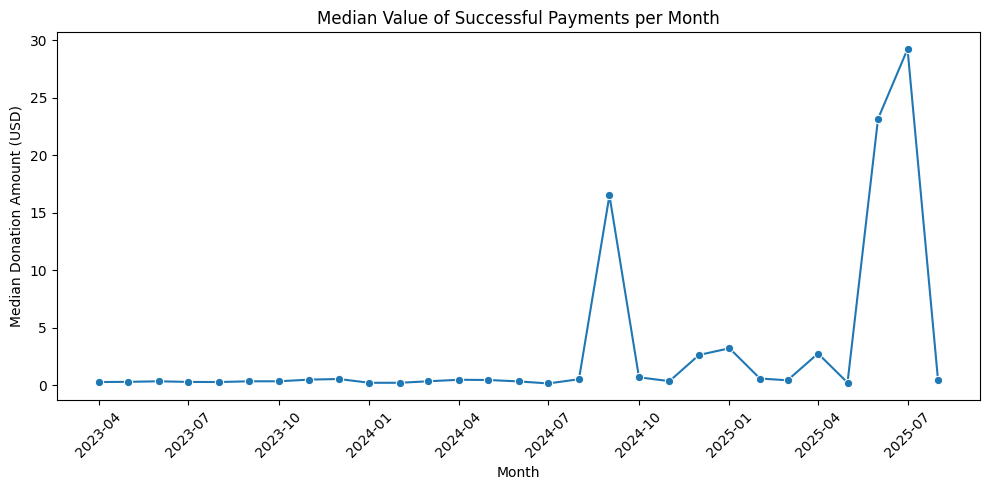

In [38]:
# Median value of successful payments per month
monthly_median = (
    df_success
    .dropna(subset=["CREATED_AT", "DONATION_AMOUNT_USD"])
    .groupby(pd.Grouper(key="CREATED_AT", freq="MS"))["DONATION_AMOUNT_USD"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_median, x="CREATED_AT", y="DONATION_AMOUNT_USD", marker="o")
plt.title("Median Value of Successful Payments per Month")
plt.xlabel("Month")
plt.ylabel("Median Donation Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


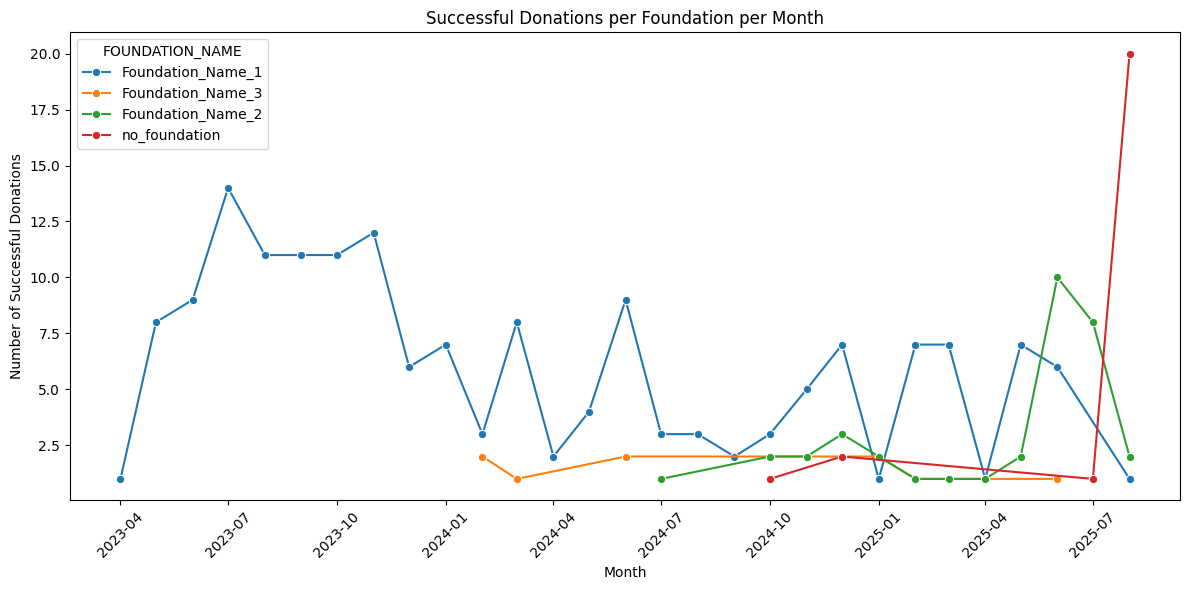

In [7]:
# Number of successful donations per foundation per month
monthly_foundation_counts = (
    df_success
    .dropna(subset=["CREATED_AT"])
    .groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "FOUNDATION_NAME"])
    .size()
    .reset_index(name="donation_count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_foundation_counts,
    x="CREATED_AT",
    y="donation_count",
    hue="FOUNDATION_NAME",
    marker="o"
)
plt.title("Successful Donations per Foundation per Month")
plt.xlabel("Month")
plt.ylabel("Number of Successful Donations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

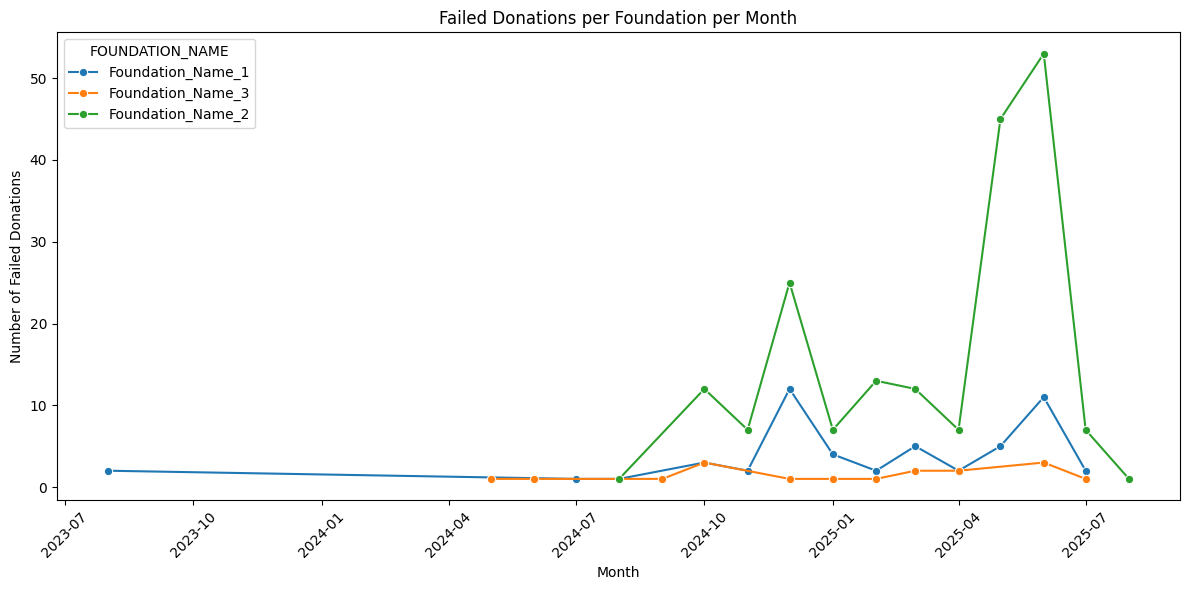

In [9]:
# Number of failed donations per foundation per month
monthly_foundation_counts = (
    df_failed
    .dropna(subset=["CREATED_AT"])
    .groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "FOUNDATION_NAME"])
    .size()
    .reset_index(name="donation_count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_foundation_counts,
    x="CREATED_AT",
    y="donation_count",
    hue="FOUNDATION_NAME",
    marker="o"
)
plt.title("Failed Donations per Foundation per Month")
plt.xlabel("Month")
plt.ylabel("Number of Failed Donations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

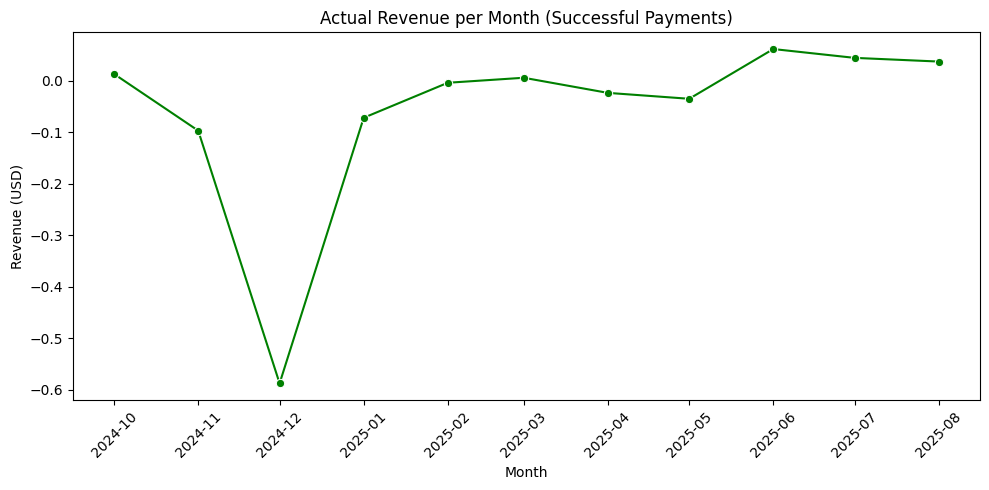

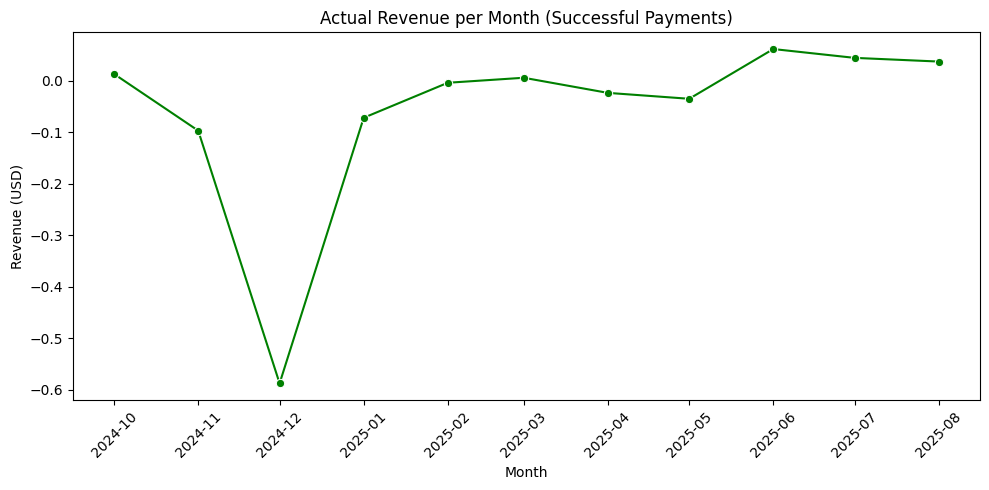

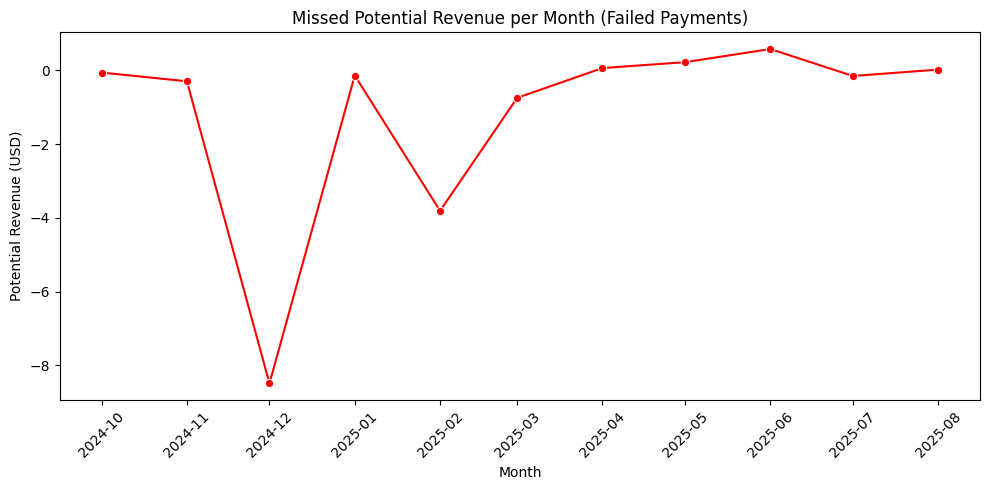

In [10]:
# --- Revenue per month: Actual (successful) vs Missed (failed) ---

# Actual revenue (successful payments)
monthly_rev_success = (
    df_success
    .dropna(subset=["CREATED_AT", "REVENUE_USD"])
    .set_index("CREATED_AT")
    .resample("MS")["REVENUE_USD"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_rev_success, x="CREATED_AT", y="REVENUE_USD", marker="o", color="green")
plt.title("Actual Revenue per Month (Successful Payments)")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Missed/potential revenue (failed payments)
monthly_rev_failed = (
    df_failed
    .dropna(subset=["CREATED_AT", "REVENUE_USD"])
    .set_index("CREATED_AT")
    .resample("MS")["REVENUE_USD"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_rev_failed, x="CREATED_AT", y="REVENUE_USD", marker="o", color="red")
plt.title("Missed Potential Revenue per Month (Failed Payments)")
plt.xlabel("Month")
plt.ylabel("Potential Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

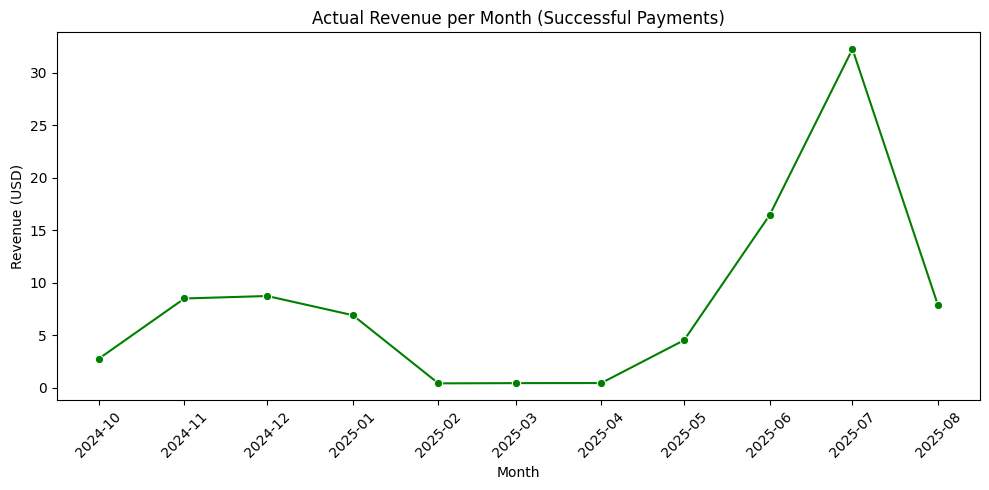

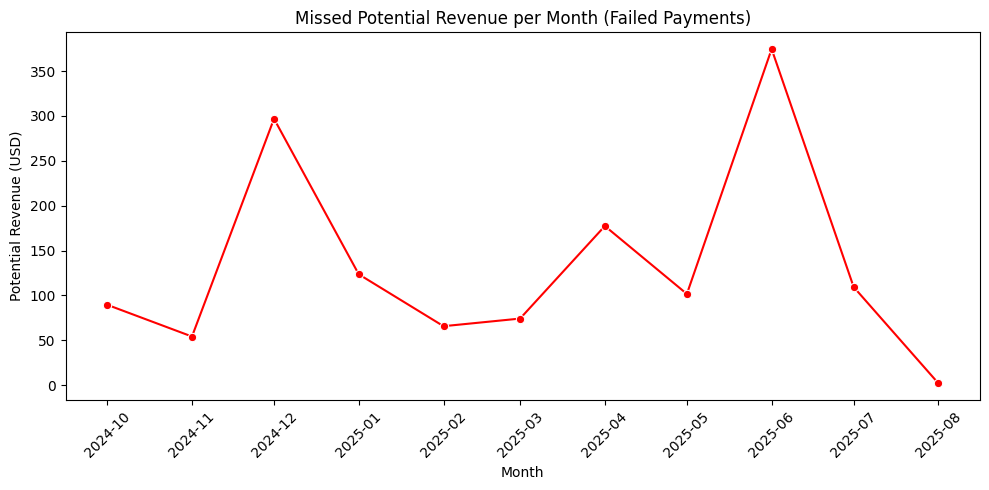

In [11]:
# --- Revenue per month: Actual (successful) vs Missed (failed) ---

# Actual revenue (successful payments)
monthly_rev_success = (
    df_success
    .dropna(subset=["CREATED_AT", "DONATION_FEE_AMOUNT_USD"])
    .groupby(pd.Grouper(key="CREATED_AT", freq="MS"))["DONATION_FEE_AMOUNT_USD"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_rev_success, x="CREATED_AT", y="DONATION_FEE_AMOUNT_USD", marker="o", color="green")
plt.title("Actual Revenue per Month (Successful Payments)")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Missed/potential revenue (failed payments)
monthly_rev_failed = (
    df_failed
    .dropna(subset=["CREATED_AT", "DONATION_FEE_AMOUNT_USD"])
    .groupby(pd.Grouper(key="CREATED_AT", freq="MS"))["DONATION_FEE_AMOUNT_USD"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_rev_failed, x="CREATED_AT", y="DONATION_FEE_AMOUNT_USD", marker="o", color="red")
plt.title("Missed Potential Revenue per Month (Failed Payments)")
plt.xlabel("Month")
plt.ylabel("Potential Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# July root-cause breakdown by value (the successful revenue spike)
x = df.copy()
x["month"] = x["CREATED_AT"].dt.to_period("M").astype(str)

july = x[x["month"] == "2025-07"].copy()

# 1) Top transactions driving July value
top_july = july.sort_values("DONATION_AMOUNT_USD", ascending=False)[
    ["DONATION_ID","CREATED_AT","DONATION_STATUS","FOUNDATION_NAME","PARTNER_NAME","ORGANISATION_NAME","DONATION_AMOUNT_USD"]
].head(15)

# 2) July value by status
july_status = july.groupby("DONATION_STATUS", as_index=False)["DONATION_AMOUNT_USD"].sum().sort_values("DONATION_AMOUNT_USD", ascending=False)

# 3) July value by foundation + partner
july_fp = july.groupby(["FOUNDATION_NAME","PARTNER_NAME"], as_index=False)["DONATION_AMOUNT_USD"].sum().sort_values("DONATION_AMOUNT_USD", ascending=False)

# 4) Share of July explained by top 5 donations
july_total = july["DONATION_AMOUNT_USD"].sum()
top5_share = top_july["DONATION_AMOUNT_USD"].head(5).sum() / july_total

top_july_small = top_july[["DONATION_ID","DONATION_STATUS","FOUNDATION_NAME","PARTNER_NAME","DONATION_AMOUNT_USD"]].head(10)
july_status_small = july_status.assign(pct=lambda d: (d["DONATION_AMOUNT_USD"] / july_total * 100).round(2))
july_fp_small = july_fp.assign(pct=lambda d: (d["DONATION_AMOUNT_USD"] / july_total * 100).round(2)).head(10)

print(f"Top 5 donation share of July total: {top5_share*100:.2f}%")
print(f"July total value (USD): {july_total:,.2f}")
display(top_july_small)
display(july_status_small)
display(july_fp_small)


Top 5 donation share of July total: 81.15%
July total value (USD): 2,811.81


/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_21448/2604459907.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = x["CREATED_AT"].dt.to_period("M").astype(str)


,DONATION_ID,DONATION_STATUS,FOUNDATION_NAME,PARTNER_NAME,DONATION_AMOUNT_USD
225,donation_000000D7Kz61ayBsAUU9r6ZEAPjhE,unable_to_pay,Foundation_Name_2,Partner_Name_1,1114.382438
36,donation_000000D88ROd0K6tOortLuPZjW4sm,disbursement_created,Foundation_Name_2,Partner_Name_1,390.110910
228,donation_000000D7jidSG869EvdyLfvwr1ZZv,unable_to_pay,Foundation_Name_2,Partner_Name_1,292.722878
81,donation_000000D7Kae9RAHEuKmZdPhPFrBIL,unable_to_pay,Foundation_Name_1,Partner_Name_1,250.000000
211,donation_000000D7KaF8bU2cfxevYANZx0gsw,unable_to_pay,Foundation_Name_2,Partner_Name_1,234.606829
170,donation_000000D7fV7brUjIufvXHL4BFy5ul,unable_to_pay,Foundation_Name_3,Partner_Name_1,67.899713
222,donation_000000D7LytK6m2cWELDozrl49qUO,unable_to_pay,Foundation_Name_2,Partner_Name_1,59.072320
221,donation_000000D7NCwOzQsbQKrQo78KCXqAH,unable_to_pay,Foundation_Name_2,Partner_Name_1,59.072320
0,donation_000000D8LWuynwldBDEQkUd3YPcZx,awaiting_disbursement_batch,Foundation_Name_2,Partner_Name_1,58.748184
223,donation_000000D7i35EwngPRw2fBBcdiPGRZ,unable_to_pay,Foundation_Name_2,Partner_Name_1,58.544576


,DONATION_STATUS,DONATION_AMOUNT_USD,pct
4,unable_to_pay,2169.485353,77.16
3,disbursement_created,507.379297,18.04
2,below_payout_threshold,76.063494,2.71
0,awaiting_disbursement_batch,58.748184,2.09
1,awaiting_donation_request,0.138194,0.00


,FOUNDATION_NAME,PARTNER_NAME,DONATION_AMOUNT_USD,pct
1,Foundation_Name_2,Partner_Name_1,2466.457576,87.72
0,Foundation_Name_1,Partner_Name_1,277.319040,9.86
2,Foundation_Name_3,Partner_Name_1,67.899713,2.41
3,no_foundation,Partner_Name_4,0.138194,0.00


In [25]:
# July root-cause breakdown — successful payments only
df["month_str"] = df["CREATED_AT"].dt.to_period("M").astype(str)
july_ok = df[(df["month_str"] == "2025-07") & (df["DONATION_STATUS"] != "unable_to_pay")].copy()

july_ok_total = july_ok["DONATION_AMOUNT_USD"].sum()

# 1) Top successful transactions
top_july_ok = july_ok.sort_values("DONATION_AMOUNT_USD", ascending=False)[
    ["DONATION_ID", "DONATION_STATUS", "FOUNDATION_NAME", "PARTNER_NAME", "ORGANISATION_NAME", "DONATION_AMOUNT_USD"]
].head(10)

# 2) Value by foundation + partner
july_ok_fp = (
    july_ok.groupby(["FOUNDATION_NAME", "PARTNER_NAME"], as_index=False)["DONATION_AMOUNT_USD"]
    .sum()
    .sort_values("DONATION_AMOUNT_USD", ascending=False)
    .assign(pct=lambda d: (d["DONATION_AMOUNT_USD"] / july_ok_total * 100).round(1))
)

# 3) Value by organisation (top 10)
july_ok_org = (
    july_ok.groupby("ORGANISATION_NAME", as_index=False)["DONATION_AMOUNT_USD"]
    .sum()
    .sort_values("DONATION_AMOUNT_USD", ascending=False)
    .assign(pct=lambda d: (d["DONATION_AMOUNT_USD"] / july_ok_total * 100).round(1))
    .head(10)
)

# 4) Top N share
for n in [1, 3, 5]:
    share = top_july_ok["DONATION_AMOUNT_USD"].head(n).sum() / july_ok_total * 100
    print(f"Top {n} successful donation(s) = {share:.1f}% of July successful total")

print(f"\nJuly 2025 — Successful payments only")
print(f"Total value: ${july_ok_total:,.2f} across {len(july_ok)} donations\n")

print("=== Top transactions ===")
display(top_july_ok)

print("=== By Foundation + Partner ===")
display(july_ok_fp)

print("=== Top organisations by value ===")
display(july_ok_org)


Top 1 successful donation(s) = 60.7% of July successful total
Top 3 successful donation(s) = 77.2% of July successful total
Top 5 successful donation(s) = 89.0% of July successful total

July 2025 — Successful payments only
Total value: $642.33 across 9 donations

=== Top transactions ===


/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_21448/2614809949.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month_str"] = df["CREATED_AT"].dt.to_period("M").astype(str)


,DONATION_ID,DONATION_STATUS,FOUNDATION_NAME,PARTNER_NAME,ORGANISATION_NAME,DONATION_AMOUNT_USD
36,donation_000000D88ROd0K6tOortLuPZjW4sm,disbursement_created,Foundation_Name_2,Partner_Name_1,Organisation_Name_48,390.110910
0,donation_000000D8LWuynwldBDEQkUd3YPcZx,awaiting_disbursement_batch,Foundation_Name_2,Partner_Name_1,Organisation_Name_87,58.748184
33,donation_000000D8Q9kbDFSSQWnHS2eccHeYH,disbursement_created,Foundation_Name_2,Partner_Name_1,Organisation_Name_33,47.041738
29,donation_000000D8VjKo7ml5MJudnZGg4jyKb,below_payout_threshold,Foundation_Name_2,Partner_Name_1,Organisation_Name_80,46.808334
30,donation_000000D8BOfvEJIz314ABgY8eA49M,below_payout_threshold,Foundation_Name_2,Partner_Name_1,Organisation_Name_110,29.255160
37,donation_000000D7jiFljqW1HDtNlkYhZFml9,disbursement_created,Foundation_Name_2,Partner_Name_1,Organisation_Name_48,23.417830
38,donation_000000D7ji0wD1RtN5wsj9gCCvcOg,disbursement_created,Foundation_Name_2,Partner_Name_1,Organisation_Name_48,23.417830
43,donation_000000D7qtD5eVYeRjGwhLY8I9BCN,disbursement_created,Foundation_Name_2,Partner_Name_1,Organisation_Name_48,23.390989
28,donation_000000D7osHoabyWI9y4920fkRWNA,awaiting_donation_request,no_foundation,Partner_Name_4,Organisation_Name_130,0.138194


=== By Foundation + Partner ===


,FOUNDATION_NAME,PARTNER_NAME,DONATION_AMOUNT_USD,pct
0,Foundation_Name_2,Partner_Name_1,642.190975,100.0
1,no_foundation,Partner_Name_4,0.138194,0.0


=== Top organisations by value ===


,ORGANISATION_NAME,DONATION_AMOUNT_USD,pct
3,Organisation_Name_48,460.337559,71.7
5,Organisation_Name_87,58.748184,9.1
2,Organisation_Name_33,47.041738,7.3
4,Organisation_Name_80,46.808334,7.3
0,Organisation_Name_110,29.255160,4.6
1,Organisation_Name_130,0.138194,0.0


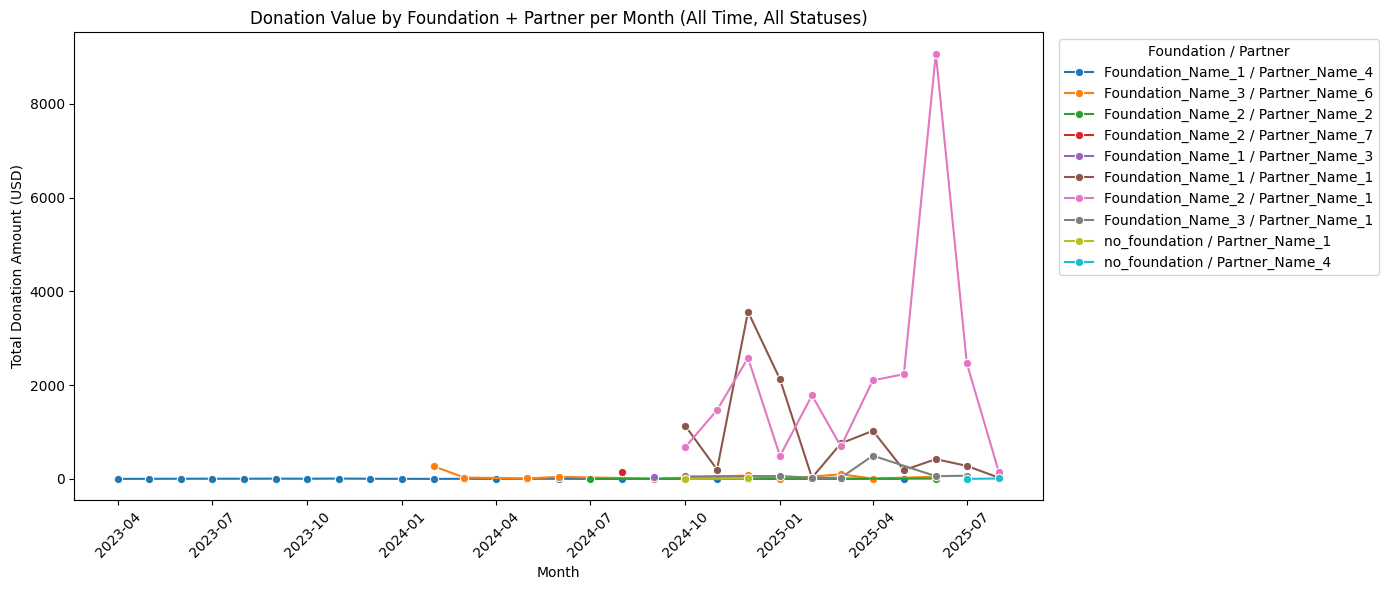

In [20]:
# Donation value by Foundation + Partner across all time
df["fp_label"] = df["FOUNDATION_NAME"] + " / " + df["PARTNER_NAME"]

monthly_fp = (
    df
    .dropna(subset=["CREATED_AT", "DONATION_AMOUNT_USD"])
    .groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "fp_label"])["DONATION_AMOUNT_USD"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_fp, x="CREATED_AT", y="DONATION_AMOUNT_USD", hue="fp_label", marker="o")
plt.title("Donation Value by Foundation + Partner per Month (All Time, All Statuses)")
plt.xlabel("Month")
plt.ylabel("Total Donation Amount (USD)")
plt.xticks(rotation=45)
plt.legend(title="Foundation / Partner", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

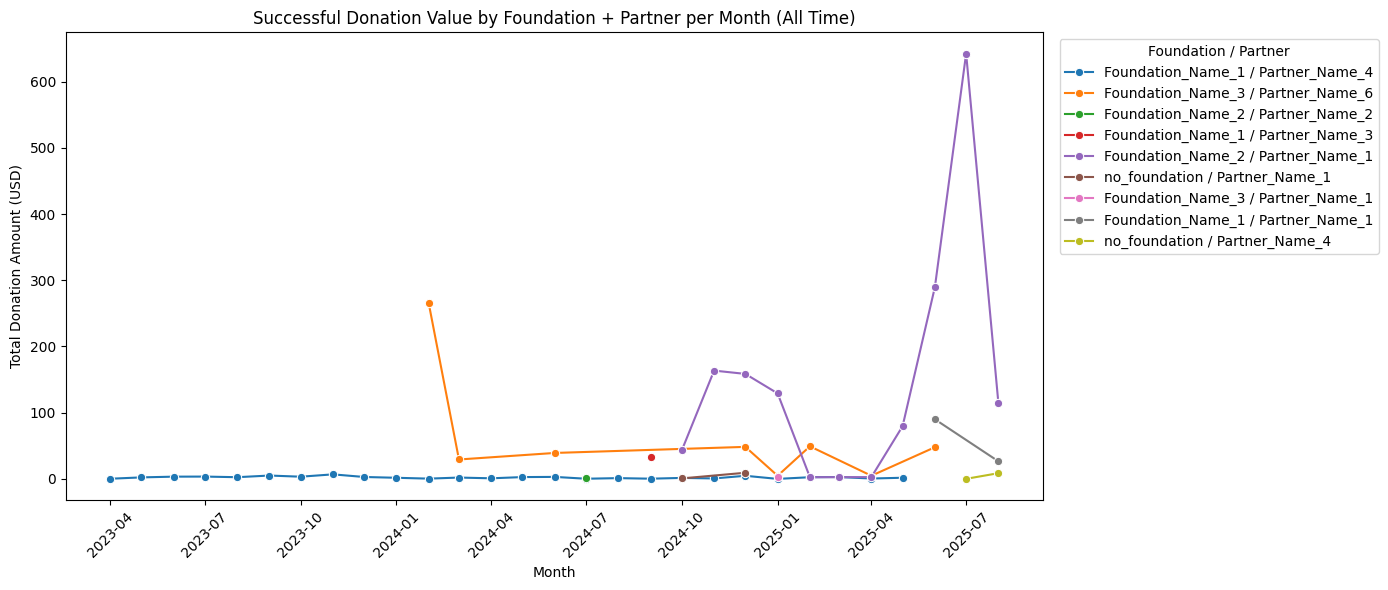

In [28]:
# Successful donation value by Foundation + Partner across all time
monthly_fp_success = (
    df[df["DONATION_STATUS"] != "unable_to_pay"]
    .dropna(subset=["CREATED_AT", "DONATION_AMOUNT_USD"])
    .groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "fp_label"])["DONATION_AMOUNT_USD"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_fp_success, x="CREATED_AT", y="DONATION_AMOUNT_USD", hue="fp_label", marker="o")
plt.title("Successful Donation Value by Foundation + Partner per Month (All Time)")
plt.xlabel("Month")
plt.ylabel("Total Donation Amount (USD)")
plt.xticks(rotation=45)
plt.legend(title="Foundation / Partner", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


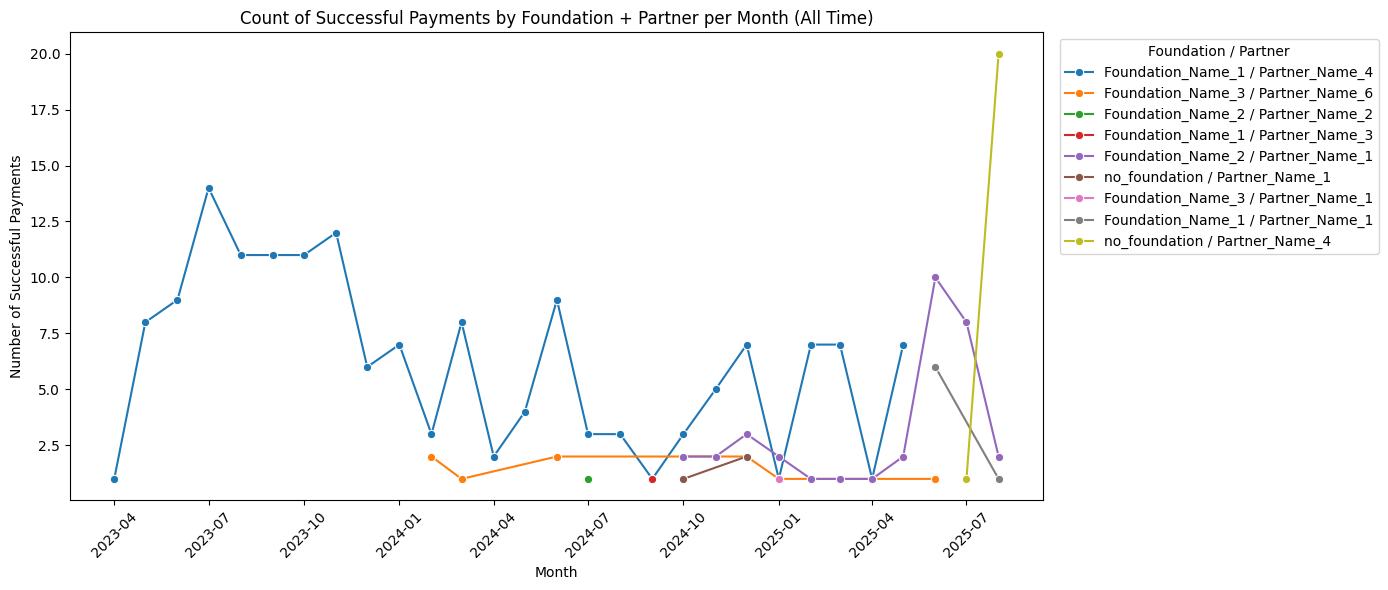

In [33]:
# Count of successful payments by Foundation + Partner across all time
monthly_fp_count = (
    df[df["DONATION_STATUS"] != "unable_to_pay"]
    .dropna(subset=["CREATED_AT"])
    .groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "fp_label"])
    .size()
    .reset_index(name="donation_count")
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_fp_count, x="CREATED_AT", y="donation_count", hue="fp_label", marker="o")
plt.title("Count of Successful Payments by Foundation + Partner per Month (All Time)")
plt.xlabel("Month")
plt.ylabel("Number of Successful Payments")
plt.xticks(rotation=45)
plt.legend(title="Foundation / Partner", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


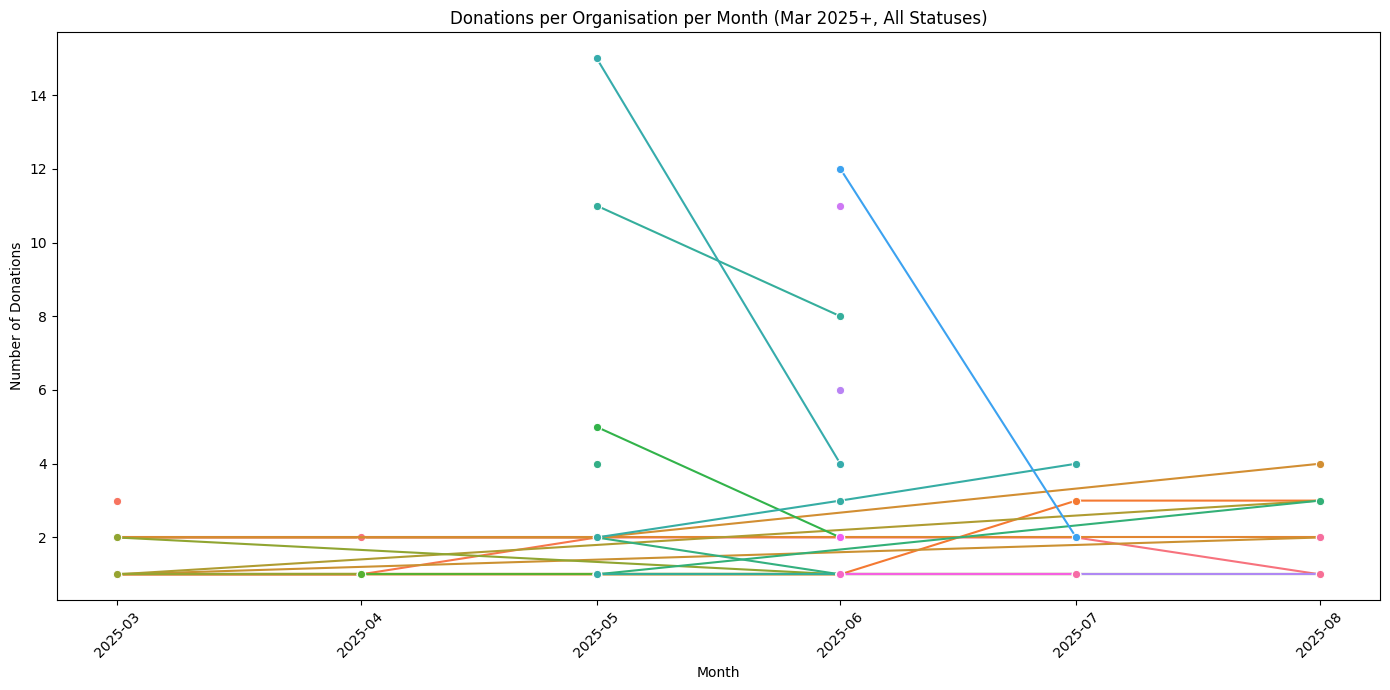

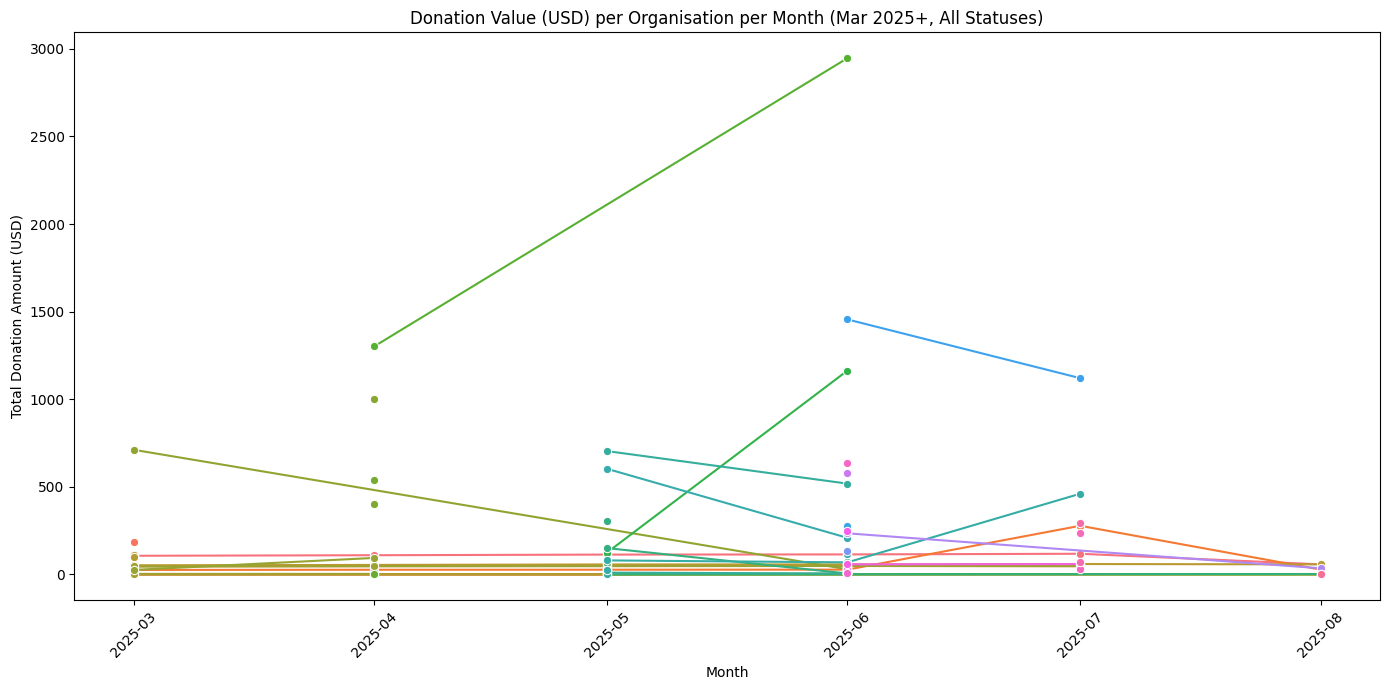

Top 10 organisations by value in July 2025:
    ORGANISATION_NAME  count   total_usd
 Organisation_Name_13      2 1120.247677
 Organisation_Name_48      4  460.337559
  Organisation_Name_9      1  292.722878
Organisation_Name_130      3  277.457234
 Organisation_Name_37      1  234.606829
Organisation_Name_104      2  117.616896
  Organisation_Name_7      1   67.899713
 Organisation_Name_44      1   59.072320
 Organisation_Name_87      1   58.748184
 Organisation_Name_33      1   47.041738


In [27]:
# Donations per organisation per month (March 2025 onwards, all statuses)
df_recent = df[df["CREATED_AT"] >= "2025-03-01"].copy()

monthly_org = (
    df_recent
    .dropna(subset=["CREATED_AT"])
    .groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "ORGANISATION_NAME"])
    .agg(count=("DONATION_ID", "count"), total_usd=("DONATION_AMOUNT_USD", "sum"))
    .reset_index()
)

# Plot donation count per org per month
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_org, x="CREATED_AT", y="count", hue="ORGANISATION_NAME", marker="o", legend=False)
plt.title("Donations per Organisation per Month (Mar 2025+, All Statuses)")
plt.xlabel("Month")
plt.ylabel("Number of Donations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot total donation value per org per month
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_org, x="CREATED_AT", y="total_usd", hue="ORGANISATION_NAME", marker="o", legend=False)
plt.title("Donation Value (USD) per Organisation per Month (Mar 2025+, All Statuses)")
plt.xlabel("Month")
plt.ylabel("Total Donation Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show top 10 orgs by July value for reference
july_top = monthly_org[monthly_org["CREATED_AT"].dt.month == 7].sort_values("total_usd", ascending=False).head(10)
print("Top 10 organisations by value in July 2025:")
print(july_top[["ORGANISATION_NAME", "count", "total_usd"]].to_string(index=False))


/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_21448/4167067748.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_story["month"] = df_story["CREATED_AT"].dt.to_period("M").astype(str)
/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_21448/4167067748.py:34: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month_str"] = df["CREATED_AT"].dt.to_period("M").astype(str)


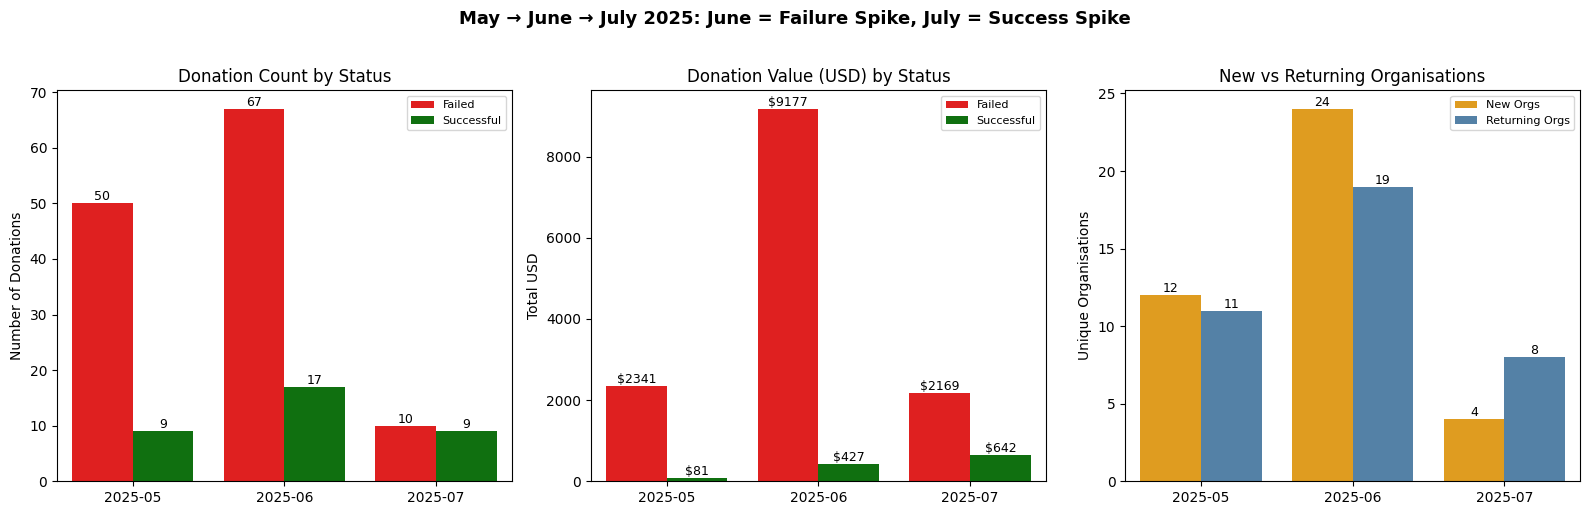

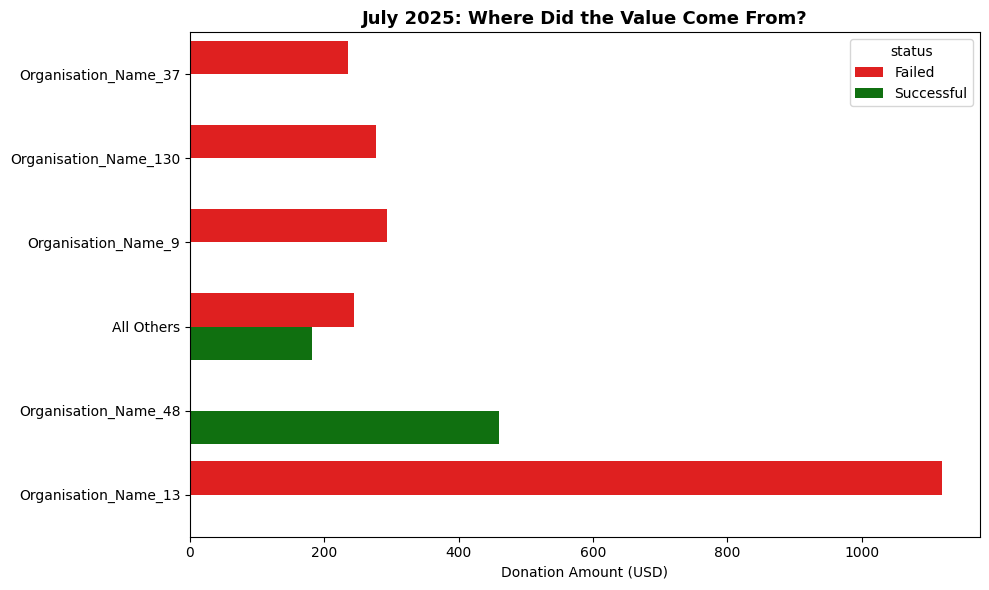

In [26]:
# === May → June → July story: June = failure spike, July = success spike ===

df_story = df.copy()
df_story["month"] = df_story["CREATED_AT"].dt.to_period("M").astype(str)
df_story = df_story[df_story["month"].isin(["2025-05", "2025-06", "2025-07"])]
df_story["status"] = df_story["DONATION_STATUS"].apply(lambda s: "Failed" if s == "unable_to_pay" else "Successful")

# --- 1. Donation count: failed vs successful per month ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

count_data = df_story.groupby(["month", "status"]).size().reset_index(name="count")
sns.barplot(data=count_data, x="month", y="count", hue="status",
            palette={"Failed": "red", "Successful": "green"}, ax=axes[0])
axes[0].set_title("Donation Count by Status")
axes[0].set_ylabel("Number of Donations")
axes[0].set_xlabel("")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", fontsize=9)
axes[0].legend(fontsize=8)

# --- 2. Total value: failed vs successful per month ---
value_data = df_story.groupby(["month", "status"])["DONATION_AMOUNT_USD"].sum().reset_index()
sns.barplot(data=value_data, x="month", y="DONATION_AMOUNT_USD", hue="status",
            palette={"Failed": "red", "Successful": "green"}, ax=axes[1])
axes[1].set_title("Donation Value (USD) by Status")
axes[1].set_ylabel("Total USD")
axes[1].set_xlabel("")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="$%.0f", fontsize=9)
axes[1].legend(fontsize=8)

# --- 3. New vs returning organisations per month ---
# Use month string comparison to avoid tz issues
df["month_str"] = df["CREATED_AT"].dt.to_period("M").astype(str)

new_counts = []
for m in ["2025-05", "2025-06", "2025-07"]:
    all_before = set(df[df["month_str"] < m]["ORGANISATION_NAME"].dropna().unique())
    month_orgs = set(df_story[df_story["month"] == m]["ORGANISATION_NAME"].dropna().unique())
    new_counts.append({"month": m, "type": "New Orgs", "count": len(month_orgs - all_before)})
    new_counts.append({"month": m, "type": "Returning Orgs", "count": len(month_orgs & all_before)})

new_df = pd.DataFrame(new_counts)
sns.barplot(data=new_df, x="month", y="count", hue="type",
            palette={"New Orgs": "orange", "Returning Orgs": "steelblue"}, ax=axes[2])
axes[2].set_title("New vs Returning Organisations")
axes[2].set_ylabel("Unique Organisations")
axes[2].set_xlabel("")
for c in axes[2].containers:
    axes[2].bar_label(c, fmt="%.0f", fontsize=9)
axes[2].legend(fontsize=8)

plt.suptitle("May → June → July 2025: June = Failure Spike, July = Success Spike", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- 4. Where did July's successful value come from? Top orgs ---
july_only = df_story[df_story["month"] == "2025-07"].copy()
top_orgs = july_only.groupby("ORGANISATION_NAME")["DONATION_AMOUNT_USD"].sum().sort_values(ascending=False).head(5).index.tolist()
july_only["org_label"] = july_only["ORGANISATION_NAME"].apply(lambda o: o if o in top_orgs else "All Others")

org_status = july_only.groupby(["org_label", "status"])["DONATION_AMOUNT_USD"].sum().reset_index()
order = july_only.groupby("org_label")["DONATION_AMOUNT_USD"].sum().sort_values(ascending=True).index.tolist()

plt.figure(figsize=(10, 6))
sns.barplot(data=org_status, y="org_label", x="DONATION_AMOUNT_USD", hue="status",
            palette={"Failed": "red", "Successful": "green"}, order=order)
plt.title("July 2025: Where Did the Value Come From?", fontsize=13, fontweight="bold")
plt.xlabel("Donation Amount (USD)")
plt.ylabel("")
plt.tight_layout()
plt.show()


=== Organisation_Name_48 — all donations ===
                      CREATED_AT      DONATION_STATUS   FOUNDATION_NAME   PARTNER_NAME  DONATION_AMOUNT_USD
2025-05-27 06:54:45.821000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            22.752608
2025-05-27 09:43:56.660000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            56.881521
2025-06-10 08:45:19.058000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            22.836001
2025-06-10 08:59:27.438000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            22.836001
2025-06-11 15:42:04.218000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            22.867855
2025-07-11 09:28:16.920000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            23.417830
2025-07-11 09:30:30.828000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1            23.417830
2025-07-14 06:44:52.638000+00:00 disbursement_created Foundation_Name_2 Partner_Name_1     

/var/folders/pc/w4rfj05x6vj099qm1158dcyw0000gn/T/ipykernel_21448/151787408.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  org48["month_str"] = org48["CREATED_AT"].dt.to_period("M").astype(str)


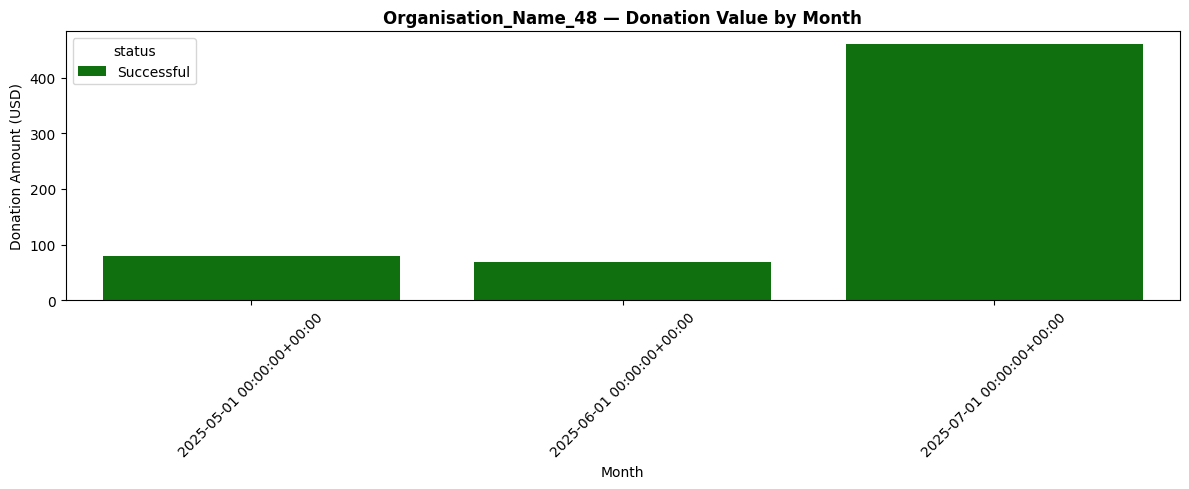

In [32]:
# Organisation_Name_48 — full history
org48 = df[df["ORGANISATION_NAME"] == "Organisation_Name_48"].copy()
org48["month_str"] = org48["CREATED_AT"].dt.to_period("M").astype(str)

# Monthly summary
org48_monthly = (
    org48.groupby(["month_str", "DONATION_STATUS"])
    .agg(count=("DONATION_ID", "count"), total=("DONATION_AMOUNT_USD", "sum"))
    .reset_index()
)

print("=== Organisation_Name_48 — all donations ===")
print(org48[["CREATED_AT","DONATION_STATUS","FOUNDATION_NAME","PARTNER_NAME","DONATION_AMOUNT_USD"]].sort_values("CREATED_AT").to_string(index=False))

print(f"\nTotal donations: {len(org48)}")
print(f"First seen: {org48['CREATED_AT'].min().date()}")
print(f"Total value (all): ${org48['DONATION_AMOUNT_USD'].sum():,.2f}")
print(f"Total value (successful): ${org48[org48['DONATION_STATUS'] != 'unable_to_pay']['DONATION_AMOUNT_USD'].sum():,.2f}")

# Plot their history
org48_plot = (
    org48.groupby([pd.Grouper(key="CREATED_AT", freq="MS"), "DONATION_STATUS"])["DONATION_AMOUNT_USD"]
    .sum()
    .reset_index()
)
org48_plot["status"] = org48_plot["DONATION_STATUS"].apply(lambda s: "Failed" if s == "unable_to_pay" else "Successful")

plt.figure(figsize=(12, 5))
sns.barplot(data=org48_plot, x="CREATED_AT", y="DONATION_AMOUNT_USD", hue="status",
            palette={"Failed": "red", "Successful": "green"})
plt.title("Organisation_Name_48 — Donation Value by Month", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Donation Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
